```text
Ablation_Cross_Validation
│
├── KFold loop
│   ├── Baseline model (todas as features)
│   │     └── calcular métricas
│   ├── Para cada feature:
│   │     ├── remover feature
│   │     ├── treinar modelo
│   │     └── calcular métricas
│   │
│   └── guardar resultados por fold
│
└── devolver DataFrame completo
```

In [1]:
import numpy as np
import pandas as pd

from sklearn.model_selection import KFold
from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error
)
from sklearn.linear_model import LinearRegression

### Helper Function: Calculate the Metrics

In [3]:
def calculate_metrics(y_true, y_pred, n_features):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    # Adjusted R²
    n = len(y_true)
    adjusted_r2 = 1 - (1 - r2) * (n - 1) / (n - n_features - 1)

    # MAPE (proteger divisão por zero)
    mape = np.mean(np.abs((y_true - y_pred) / np.clip(y_true, 1e-8, None))) * 100

    return {
        "r2": r2,
        "adjusted_r2": adjusted_r2,
        "rmse": rmse,
        "mae": mae,
        "mse": mse,
        "mape": mape
    }


### Base Main Function - Ablation Cross Validation

In [ ]:
'''def ablation_cross_validation(
    X,
    y,
    model,
    cv_folds=5,
    features_to_test=None,
    random_state=42,
    save_csv_path=None
):
    """
    Perform ablation study with k-fold cross-validation.

    Returns a DataFrame with per-fold metrics for:
    - Full model
    - One-feature-removed models
    """

    if features_to_test is None:
        features_to_test = X.columns.tolist()

    kf = KFold(n_splits=cv_folds, shuffle=True, random_state=random_state)

    results = []

    for fold, (train_idx, test_idx) in enumerate(kf.split(X), start=1):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        # ==========================
        # 🔹 BASELINE MODEL
        # ==========================
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        base_metrics = calculate_metrics(
            y_test,
            y_pred,
            n_features=X_train.shape[1]
        )

        results.append({
            "model_variant": "Baseline",
            "features_removed": "None",
            "fold": fold,
            **base_metrics
        })

        baseline_r2 = base_metrics["r2"]
        baseline_rmse = base_metrics["rmse"]

        # ==========================
        # 🔹 ABLATION: ONE FEATURE AT A TIME
        # ==========================
        for feature in features_to_test:
            X_train_abl = X_train.drop(columns=[feature])
            X_test_abl = X_test.drop(columns=[feature])

            model.fit(X_train_abl, y_train)
            y_pred_abl = model.predict(X_test_abl)

            abl_metrics = calculate_metrics(
                y_test,
                y_pred_abl,
                n_features=X_train_abl.shape[1]
            )

            results.append({
                "model_variant": f"- {feature}",
                "features_removed": feature,
                "fold": fold,
                **abl_metrics,
                "delta_r2": abl_metrics["r2"] - baseline_r2,
                "delta_rmse": abl_metrics["rmse"] - baseline_rmse
            })

    results_df = pd.DataFrame(results)

    if save_csv_path:
        results_df.to_csv(save_csv_path, index=False)

    return results_df'''



For each group size:

- The **top-N features** are selected from the initial ranking
- **All possible feature combinations** within this group are evaluated
- Each combination is tested using **k-fold cross-validation**
- The **best-performing subset** is retained

This ensures that:
- Feature interactions are considered
- The selection is not biased by a single ordering
- The final subset is empirically optimal

---

## Cross-Validation Setup

- **Model:** Any scikit-learn compatible estimator  
- **Validation Strategy:** K-Fold Cross-Validation  
- **Number of Folds:** 5  
- **Shuffling:** Enabled with a fixed random seed  

Each feature subset is evaluated independently on each fold, ensuring robustness and preventing data leakage.

---

## Evaluation Metrics

This framework evaluates **one primary metric at a time**, selected during initialization.

### Supported Metrics

- **R² (Coefficient of Determination)**  
  Measures the proportion of variance explained by the model  
  → *Higher is better*

- **MSE (Mean Squared Error)**  
  Penalizes larger prediction errors more strongly  
  → *Lower is better*

- **Accuracy** *(for classification tasks)*  
  Measures the proportion of correct predictions  
  → *Higher is better*

The ablation logic automatically adapts to whether the selected metric should be **maximized** or **minimized**.

---

## Feature Importance Interpretation

Feature importance is computed as the **average performance degradation** caused by feature removal across folds:

- **Positive importance:** Feature contributes positively to performance
- **Zero or near zero:** Feature has minimal impact
- **Negative importance:** Feature removal improves performance, suggesting noise or redundancy

---

## Progressive Results Structure

Each evaluated strategy stores the following information:

| Field | Description |
|-----|------------|
| `strategy` | Feature selection strategy (e.g., `all_features`, `top_3_best_combo`) |
| `n_features` | Number of features used |
| `features` | Selected feature subset |
| `mean_score` | Mean cross-validated performance |
| `std_score` | Standard deviation across folds |
| `scores` | Raw fold-level scores |
| `elapsed_time` | Evaluation time (when available) |

---

## Interpretation of Results

- **Similar or better performance with fewer features**  
  → Model can be simplified without loss of predictive power

- **Performance degradation after removing features**  
  → Removed features are essential

- **Performance improvement after feature removal**  
  → Original model likely suffers from noise or overfitting

---

## Why Progressive Ablation Matters

This approach goes beyond standard feature selection techniques by:

- Evaluating **feature interactions**, not just individual importance
- Avoiding greedy or one-shot selection
- Providing **transparent and empirical justification** for feature reduction
- Improving **model interpretability and generalization**

---

## Conclusion

The progressive ablation study provides a **systematic, cross-validated, and interpretable framework** for feature selection.  
By combining individual feature importance with subset evaluation, it identifies **compact, high-performing feature sets**, leading to simpler, more robust, and more interpretable models.

PROGRESSIVE ABLATION STUDY DEMONSTRATION
Dataset: 300 samples, 12 features
Informative features: 6 (synthetic)
Model: Random Forest Regressor
Metric: R² (higher is better)
Cross-validation: 5 folds

🏁 STARTING PROGRESSIVE ABLATION ANALYSIS
   This will show each combination as it's being tested...

STEP 1: INITIAL ABLATION STUDY
Testing baseline with all 12 features...

  Fold 1/5
  Training with ALL 12 features...
  Testing removal of each feature...

  Fold 2/5
  Training with ALL 12 features...
  Testing removal of each feature...

  Fold 3/5
  Training with ALL 12 features...
  Testing removal of each feature...

  Fold 4/5
  Training with ALL 12 features...
  Testing removal of each feature...

  Fold 5/5
  Training with ALL 12 features...
  Testing removal of each feature...

✓ Baseline with all 12 features:
  R2: 0.8174 ± 0.0362

✓ Feature importance ranking completed!

STEP 2: PROGRESSIVE ABLATION ANALYSIS
Testing sequence: All → [6, 4, 3, 2, 1]
For each step, testing ALL combi

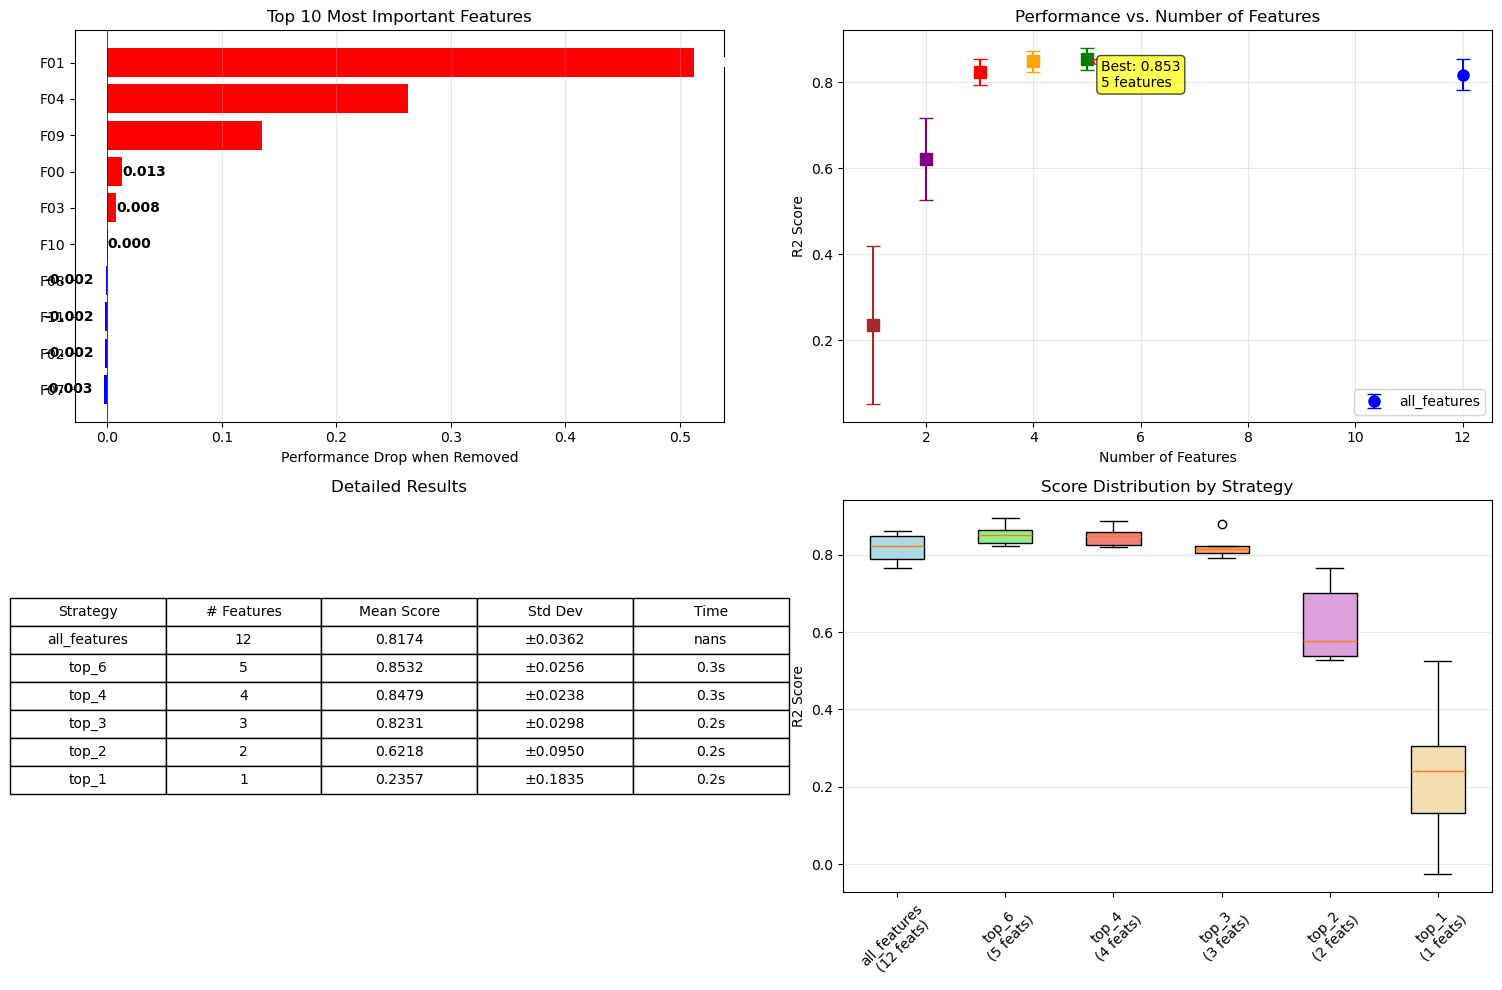


PROGRESSIVE ABLATION STUDY - FINAL SUMMARY

🎯 OPTIMAL FEATURE SUBSET FOUND:
   ┌──────────────────────────────────────────────────────┐
   │ Strategy: top_6_best_combo                    │
   │ Features:  5 features        │
   │ Performance (R2): 0.8532 ± 0.0256 │
   │ Time: 0.3s                               │
   └──────────────────────────────────────────────────────┘
   Feature list: ['F01', 'F04', 'F09', 'F00', 'F03']

📊 COMPARISON TO BASELINE (All Features):
   Baseline (12 features): 0.8174
   Optimal (5 features): 0.8532
   Improvement: ↑ 0.0358 (HIGHER)
   Features reduced by: 7 (58.3%)

🔍 FEATURE IMPORTANCE RANKING (Top 8):
   Rank Feature      Importance   Impact    
   ──── ──────────── ──────────── ──────────
      1 F01                0.5125 IMPORTANT 
      2 F04                0.2623 IMPORTANT 
      3 F09                0.1353 IMPORTANT 
      4 F00                0.0129 IMPORTANT 
      5 F03                0.0078 IMPORTANT 
      6 F10                0.0004 IMPORTAN

In [8]:
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold
from sklearn.base import clone
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score
import matplotlib.pyplot as plt
from itertools import combinations
from tqdm import tqdm
import warnings
import time
warnings.filterwarnings('ignore')

class ProgressiveAblationSelector:
    """
    Progressive ablation study testing decreasing feature subsets:
    All features → Top 6 → Top 4 → Top 3 → Top 2 → Top 1
    """
    
    def __init__(self, model, metric='r2', cv_folds=5, random_state=42, verbose=True):
        """
        Args:
            model: Sklearn-compatible model
            metric: Evaluation metric ('r2', 'mse', 'accuracy')
            cv_folds: Number of cross-validation folds
            random_state: Random seed for reproducibility
            verbose: Print detailed progress
        """
        self.model = model
        self.metric = metric
        self.cv_folds = cv_folds
        self.random_state = random_state
        self.verbose = verbose
        self.results = {}
        self.feature_importance_df = None
        self.progressive_results = []
        
    def _calculate_metric(self, y_true, y_pred):
        """Calculate the specified evaluation metric."""
        if self.metric == 'r2':
            return r2_score(y_true, y_pred)
        elif self.metric == 'mse':
            return mean_squared_error(y_true, y_pred)
        elif self.metric == 'accuracy':
            return accuracy_score(y_true, y_pred)
        else:
            raise ValueError(f"Unsupported metric: {self.metric}")
    
    def perform_initial_ablation(self, X, y, feature_names=None):
        """
        Step 1: Initial ablation study with all features.
        Ranks features from most important to least important.
        """
        if feature_names is None:
            feature_names = [f'Feature_{i}' for i in range(X.shape[1])]
        
        n_features = len(feature_names)
        kf = KFold(n_splits=self.cv_folds, shuffle=True, random_state=self.random_state)
        
        # Store results for each feature removal
        fold_results = {feature: [] for feature in feature_names}
        baseline_scores = []
        
        print("\n" + "="*70)
        print("STEP 1: INITIAL ABLATION STUDY")
        print("="*70)
        print(f"Testing baseline with all {n_features} features...")
        
        for fold, (train_idx, val_idx) in enumerate(kf.split(X), 1):
            if self.verbose:
                print(f"\n  Fold {fold}/{self.cv_folds}")
                print(f"  Training with ALL {n_features} features...")
            
            X_train, X_val = X[train_idx], X[val_idx]
            y_train, y_val = y[train_idx], y[val_idx]
            
            # Baseline with all features
            model_base = clone(self.model)
            model_base.fit(X_train, y_train)
            y_pred_base = model_base.predict(X_val)
            baseline_score = self._calculate_metric(y_val, y_pred_base)
            baseline_scores.append(baseline_score)
            
            if self.verbose:
                print(f"  Testing removal of each feature...")
            
            # Test removing each feature
            for i, feature in enumerate(feature_names):
                # Create dataset without this feature
                X_train_ablated = np.delete(X_train, i, axis=1)
                X_val_ablated = np.delete(X_val, i, axis=1)
                
                # Train and evaluate
                model_ablated = clone(self.model)
                model_ablated.fit(X_train_ablated, y_train)
                y_pred_ablated = model_ablated.predict(X_val_ablated)
                ablated_score = self._calculate_metric(y_val, y_pred_ablated)
                
                # Calculate performance drop (importance)
                # Higher drop = more important feature
                performance_drop = baseline_score - ablated_score
                fold_results[feature].append(performance_drop)
        
        # Average results across folds
        feature_importance = {
            feature: np.mean(scores) for feature, scores in fold_results.items()
        }
        
        # Create DataFrame sorted by importance (highest drop first)
        self.feature_importance_df = pd.DataFrame({
            'feature': list(feature_importance.keys()),
            'importance': list(feature_importance.values()),
            'abs_importance': [abs(v) for v in feature_importance.values()]
        }).sort_values('importance', ascending=False).reset_index(drop=True)
        
        baseline_mean = np.mean(baseline_scores)
        baseline_std = np.std(baseline_scores)
        
        print(f"\n✓ Baseline with all {n_features} features:")
        print(f"  {self.metric.upper()}: {baseline_mean:.4f} ± {baseline_std:.4f}")
        
        # Store baseline result
        self.progressive_results.append({
            'n_features': n_features,
            'features': feature_names,
            'strategy': 'all_features',
            'mean_score': baseline_mean,
            'std_score': baseline_std,
            'scores': baseline_scores
        })
        
        print(f"\n✓ Feature importance ranking completed!")
        return self.feature_importance_df
    
    def progressive_ablation_analysis(self, X, y, feature_names=None):
        """
        Step 2: Progressive ablation study with decreasing feature sets:
        All → Top 6 → Top 4 → Top 3 → Top 2 → Top 1
        """
        if feature_names is None:
            feature_names = [f'Feature_{i}' for i in range(X.shape[1])]
        
        if self.feature_importance_df is None:
            self.perform_initial_ablation(X, y, feature_names)
        
        n_features = len(feature_names)
        
        # Define the progressive sequence
        if n_features >= 6:
            top_n_list = [6, 4, 3, 2, 1]
        elif n_features >= 4:
            top_n_list = [4, 3, 2, 1]
        elif n_features >= 3:
            top_n_list = [3, 2, 1]
        elif n_features >= 2:
            top_n_list = [2, 1]
        else:
            top_n_list = [1]
        
        print("\n" + "="*70)
        print("STEP 2: PROGRESSIVE ABLATION ANALYSIS")
        print("="*70)
        print(f"Testing sequence: All → {top_n_list}")
        print(f"For each step, testing ALL combinations within the top features")
        
        kf = KFold(n_splits=self.cv_folds, shuffle=True, random_state=self.random_state)
        
        for top_n in top_n_list:
            # Get top N features based on initial ranking
            top_features = self.feature_importance_df.head(top_n)['feature'].tolist()
            feature_indices = [feature_names.index(f) for f in top_features]
            
            print(f"\n" + "-"*60)
            print(f"🔍 TESTING TOP {top_n} FEATURES:")
            print(f"   Features: {top_features}")
            print("-"*60)
            
            # Test different combinations within this top-N group
            best_combo_score = -np.inf if self.metric != 'mse' else np.inf
            best_combo = None
            
            total_combinations = sum(1 for r in range(1, top_n + 1) for _ in combinations(feature_indices, r))
            combo_count = 0
            
            # Test all subsets of these top N features
            for r in range(1, top_n + 1):
                for combo_indices in combinations(feature_indices, r):
                    combo_count += 1
                    combo_features = [feature_names[i] for i in combo_indices]
                    
                    if self.verbose:
                        print(f"\n  Testing combination {combo_count}/{total_combinations}:")
                        print(f"    Features ({len(combo_features)}): {combo_features}")
                    
                    X_subset = X[:, list(combo_indices)]
                    
                    # Cross-validate
                    start_time = time.time()
                    scores = []
                    
                    for fold, (train_idx, val_idx) in enumerate(kf.split(X_subset), 1):
                        X_train, X_val = X_subset[train_idx], X_subset[val_idx]
                        y_train, y_val = y[train_idx], y[val_idx]
                        
                        model = clone(self.model)
                        model.fit(X_train, y_train)
                        y_pred = model.predict(X_val)
                        score = self._calculate_metric(y_val, y_pred)
                        scores.append(score)
                    
                    mean_score = np.mean(scores)
                    std_score = np.std(scores)
                    elapsed = time.time() - start_time
                    
                    if self.verbose:
                        print(f"    Result: {mean_score:.4f} ± {std_score:.4f}")
                        print(f"    Time: {elapsed:.2f}s")
                    
                    # For MSE, lower is better; for R2/accuracy, higher is better
                    is_better = (mean_score < best_combo_score) if self.metric == 'mse' else (mean_score > best_combo_score)
                    
                    if is_better:
                        best_combo_score = mean_score
                        best_combo = {
                            'indices': combo_indices,
                            'features': combo_features,
                            'scores': scores,
                            'mean_score': mean_score,
                            'std_score': std_score,
                            'elapsed_time': elapsed
                        }
                        
                        if self.verbose:
                            print(f"    🎯 NEW BEST for top {top_n}!")
            
            if best_combo:
                self.progressive_results.append({
                    'n_features': len(best_combo['indices']),
                    'features': best_combo['features'],
                    'strategy': f'top_{top_n}_best_combo',
                    'mean_score': best_combo_score,
                    'std_score': best_combo['std_score'],
                    'scores': best_combo['scores'],
                    'elapsed_time': best_combo['elapsed_time']
                })
                
                print(f"\n✓ BEST COMBINATION for top {top_n}:")
                print(f"  Features: {len(best_combo['features'])}")
                print(f"  Score: {best_combo_score:.4f} ± {best_combo['std_score']:.4f}")
                print(f"  Features: {best_combo['features']}")
                print(f"  Time: {best_combo['elapsed_time']:.2f}s")
        
        # Convert to DataFrame and sort appropriately
        progressive_df = pd.DataFrame(self.progressive_results)
        
        # Sort by score (higher is better for R2/accuracy, lower for MSE)
        if self.metric == 'mse':
            progressive_df = progressive_df.sort_values('mean_score')
        else:
            progressive_df = progressive_df.sort_values('mean_score', ascending=False)
        
        print("\n" + "="*70)
        print("✓ PROGRESSIVE ABLATION COMPLETED!")
        print("="*70)
        
        return progressive_df
    
    def _cross_validate_subset(self, X_subset, y, kf):
        """Cross-validate model on a feature subset."""
        scores = []
        
        for train_idx, val_idx in kf.split(X_subset):
            X_train, X_val = X_subset[train_idx], X_subset[val_idx]
            y_train, y_val = y[train_idx], y[val_idx]
            
            model = clone(self.model)
            model.fit(X_train, y_train)
            y_pred = model.predict(X_val)
            score = self._calculate_metric(y_val, y_pred)
            scores.append(score)
        
        return scores
    
    def plot_results(self):
        """Plot progressive ablation results."""
        if not self.progressive_results:
            print("No progressive results to plot. Run progressive_ablation_analysis first.")
            return
        
        fig, axes = plt.subplots(2, 2, figsize=(15, 10))
        
        # Plot 1: Feature importance ranking
        if self.feature_importance_df is not None:
            ax1 = axes[0, 0]
            importance_df = self.feature_importance_df.copy()
            
            # Show top 10 or all if less than 10
            n_to_show = min(10, len(importance_df))
            top_features = importance_df.head(n_to_show)
            
            colors = ['red' if x > 0 else 'blue' for x in top_features['importance']]
            bars = ax1.barh(range(n_to_show), top_features['importance'], color=colors)
            ax1.set_yticks(range(n_to_show))
            ax1.set_yticklabels(top_features['feature'])
            ax1.invert_yaxis()
            ax1.set_xlabel('Performance Drop when Removed')
            ax1.set_title(f'Top {n_to_show} Most Important Features')
            ax1.grid(True, alpha=0.3, axis='x')
            ax1.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
            
            # Add value labels
            for i, (bar, val) in enumerate(zip(bars, top_features['importance'])):
                ax1.text(val if val > 0 else val - 0.01, i, f'{val:.3f}', 
                        va='center', ha='right' if val <= 0 else 'left',
                        color='white' if abs(val) > 0.02 else 'black',
                        fontweight='bold')
        
        # Plot 2: Performance vs Number of Features
        ax2 = axes[0, 1]
        progressive_df = pd.DataFrame(self.progressive_results)
        
        # For display, sort by n_features
        display_df = progressive_df.copy()
        display_df = display_df.sort_values('n_features')
        
        # Group by strategy type for coloring
        colors = {'all_features': 'blue', 'top_6_best_combo': 'green', 
                 'top_4_best_combo': 'orange', 'top_3_best_combo': 'red',
                 'top_2_best_combo': 'purple', 'top_1_best_combo': 'brown'}
        
        for idx, row in display_df.iterrows():
            color = colors.get(row['strategy'], 'gray')
            marker = 'o' if 'all' in row['strategy'] else 's'
            ax2.errorbar(row['n_features'], row['mean_score'], 
                        yerr=row['std_score'], fmt=marker, color=color,
                        capsize=5, markersize=8, label=row['strategy'] if idx == 0 else "")
        
        ax2.set_xlabel('Number of Features')
        ax2.set_ylabel(f'{self.metric.upper()} Score')
        ax2.set_title('Performance vs. Number of Features')
        ax2.grid(True, alpha=0.3)
        ax2.legend(loc='best')
        
        # Highlight best result
        if self.metric == 'mse':
            best_idx = progressive_df['mean_score'].idxmin()
        else:
            best_idx = progressive_df['mean_score'].idxmax()
        
        best_row = progressive_df.loc[best_idx]
        ax2.annotate(f'Best: {best_row["mean_score"]:.3f}\n{best_row["n_features"]} features',
                    xy=(best_row['n_features'], best_row['mean_score']),
                    xytext=(10, -20), textcoords='offset points',
                    arrowprops=dict(arrowstyle='->', color='red'),
                    bbox=dict(boxstyle="round,pad=0.3", facecolor="yellow", alpha=0.7))
        
        # Plot 3: Detailed results table
        ax3 = axes[1, 0]
        ax3.axis('tight')
        ax3.axis('off')
        
        # Prepare table data
        table_data = []
        for i, row in progressive_df.iterrows():
            table_data.append([
                row['strategy'].replace('_best_combo', ''),
                row['n_features'],
                f"{row['mean_score']:.4f}",
                f"±{row['std_score']:.4f}",
                f"{row.get('elapsed_time', 0):.1f}s"
            ])
        
        table = ax3.table(cellText=table_data,
                         colLabels=['Strategy', '# Features', 'Mean Score', 'Std Dev', 'Time'],
                         cellLoc='center',
                         loc='center')
        table.auto_set_font_size(False)
        table.set_fontsize(10)
        table.scale(1.2, 1.5)
        ax3.set_title('Detailed Results')
        
        # Plot 4: Score distribution for each strategy
        ax4 = axes[1, 1]
        strategies = progressive_df['strategy'].unique()
        
        boxplot_data = []
        labels = []
        for strategy in strategies:
            strategy_data = progressive_df[progressive_df['strategy'] == strategy]
            if not strategy_data.empty:
                # Get all fold scores from the first row of this strategy
                scores = strategy_data.iloc[0]['scores']
                boxplot_data.append(scores)
                labels.append(f"{strategy.replace('_best_combo', '')}\n({strategy_data.iloc[0]['n_features']} feats)")
        
        bp = ax4.boxplot(boxplot_data, labels=labels, patch_artist=True)
        
        # Color boxes
        colors_box = ['lightblue', 'lightgreen', 'lightcoral', 
                     'lightsalmon', 'plum', 'wheat']
        for patch, color in zip(bp['boxes'], colors_box[:len(boxplot_data)]):
            patch.set_facecolor(color)
        
        ax4.set_ylabel(f'{self.metric.upper()} Score')
        ax4.set_title('Score Distribution by Strategy')
        ax4.grid(True, alpha=0.3, axis='y')
        ax4.tick_params(axis='x', rotation=45)
        
        plt.tight_layout()
        plt.show()
    
    def get_optimal_features(self, top_k=1):
        """
        Get the optimal feature subset based on progressive analysis.
        
        Args:
            top_k: Return top K optimal subsets (default: best only)
        """
        if not self.progressive_results:
            return None
        
        progressive_df = pd.DataFrame(self.progressive_results)
        
        # Sort appropriately for the metric
        if self.metric == 'mse':
            progressive_df = progressive_df.sort_values('mean_score')
        else:
            progressive_df = progressive_df.sort_values('mean_score', ascending=False)
        
        optimal_subsets = []
        for i in range(min(top_k, len(progressive_df))):
            row = progressive_df.iloc[i]
            optimal_subsets.append({
                'rank': i + 1,
                'n_features': row['n_features'],
                'features': row['features'],
                'mean_score': row['mean_score'],
                'std_score': row['std_score'],
                'strategy': row['strategy'],
                'elapsed_time': row.get('elapsed_time', 0)
            })
        
        return optimal_subsets
    
    def print_summary(self):
        """Print a comprehensive summary of the analysis."""
        if not self.progressive_results:
            print("No results to summarize. Run the analysis first.")
            return
        
        print("\n" + "="*80)
        print("PROGRESSIVE ABLATION STUDY - FINAL SUMMARY")
        print("="*80)
        
        # Get optimal features
        optimal = self.get_optimal_features(top_k=1)[0]
        
        print(f"\n🎯 OPTIMAL FEATURE SUBSET FOUND:")
        print(f"   ┌──────────────────────────────────────────────────────┐")
        print(f"   │ Strategy: {optimal['strategy']:35s} │")
        print(f"   │ Features: {optimal['n_features']:2d} {'feature' if optimal['n_features'] == 1 else 'features':15s} │")
        print(f"   │ Performance ({self.metric.upper()}): {optimal['mean_score']:.4f} ± {optimal['std_score']:.4f} │")
        print(f"   │ Time: {optimal.get('elapsed_time', 0):.1f}s{' ':30s} │")
        print(f"   └──────────────────────────────────────────────────────┘")
        print(f"   Feature list: {optimal['features']}")
        
        print(f"\n📊 COMPARISON TO BASELINE (All Features):")
        baseline = self.progressive_results[0]
        
        if self.metric == 'mse':
            improvement = baseline['mean_score'] - optimal['mean_score']
            better = "LOWER" if improvement > 0 else "HIGHER"
            direction = "↓" if improvement > 0 else "↑"
        else:
            improvement = optimal['mean_score'] - baseline['mean_score']
            better = "HIGHER" if improvement > 0 else "LOWER"
            direction = "↑" if improvement > 0 else "↓"
        
        print(f"   Baseline ({baseline['n_features']} features): {baseline['mean_score']:.4f}")
        print(f"   Optimal ({optimal['n_features']} features): {optimal['mean_score']:.4f}")
        print(f"   Improvement: {direction} {improvement:.4f} ({better})")
        print(f"   Features reduced by: {baseline['n_features'] - optimal['n_features']} ({((baseline['n_features'] - optimal['n_features']) / baseline['n_features'] * 100):.1f}%)")
        
        print(f"\n🔍 FEATURE IMPORTANCE RANKING (Top 8):")
        if self.feature_importance_df is not None:
            print(f"   {'Rank':4s} {'Feature':12s} {'Importance':12s} {'Impact':10s}")
            print(f"   {'─'*4} {'─'*12} {'─'*12} {'─'*10}")
            for i, row in self.feature_importance_df.head(8).iterrows():
                impact = "IMPORTANT" if row['importance'] > 0 else "HARMFUL"
                color_start = "\033[92m" if row['importance'] > 0 else "\033[91m"  # Green/Red
                color_end = "\033[0m"
                print(f"   {i+1:4d} {row['feature']:12s} {color_start}{row['importance']:12.4f}{color_end} {impact:10s}")
        
        print(f"\n📈 ALL TESTED STRATEGIES (sorted by performance):")
        progressive_df = pd.DataFrame(self.progressive_results)
        
        if self.metric == 'mse':
            progressive_df = progressive_df.sort_values('mean_score')
            print(f"   {'Strategy':20s} {'Features':10s} {'MSE':12s} {'Std':8s} {'Time':8s}")
            print(f"   {'─'*20} {'─'*10} {'─'*12} {'─'*8} {'─'*8}")
        else:
            progressive_df = progressive_df.sort_values('mean_score', ascending=False)
            print(f"   {'Strategy':20s} {'Features':10s} {'R²/Acc':12s} {'Std':8s} {'Time':8s}")
            print(f"   {'─'*20} {'─'*10} {'─'*12} {'─'*8} {'─'*8}")
        
        for i, row in progressive_df.iterrows():
            strategy_name = row['strategy'].replace('_best_combo', '')
            if row['strategy'] == optimal['strategy']:
                print(f"   \033[93m▶ {strategy_name:18s} {row['n_features']:10d} {row['mean_score']:12.4f} ±{row['std_score']:.4f} {row.get('elapsed_time', 0):7.1f}s\033[0m")
            else:
                print(f"     {strategy_name:18s} {row['n_features']:10d} {row['mean_score']:12.4f} ±{row['std_score']:.4f} {row.get('elapsed_time', 0):7.1f}s")

# Example usage
if __name__ == "__main__":
    # Example with synthetic data
    from sklearn.ensemble import RandomForestRegressor
    from sklearn.datasets import make_regression
    
    # Generate synthetic data with 12 features (6 informative)
    np.random.seed(42)
    X, y = make_regression(n_samples=300, n_features=12, n_informative=6, 
                          noise=0.3, random_state=42)
    feature_names = [f'F{i:02d}' for i in range(X.shape[1])]
    
    print("="*80)
    print("PROGRESSIVE ABLATION STUDY DEMONSTRATION")
    print("="*80)
    print(f"Dataset: {X.shape[0]} samples, {X.shape[1]} features")
    print(f"Informative features: 6 (synthetic)")
    print(f"Model: Random Forest Regressor")
    print(f"Metric: R² (higher is better)")
    print(f"Cross-validation: {5} folds")
    print("="*80)
    
    # Initialize selector with verbose output
    selector = ProgressiveAblationSelector(
        model=RandomForestRegressor(n_estimators=50, random_state=42),
        metric='r2',
        cv_folds=5,
        verbose=True
    )
    
    # Run the complete analysis
    print("\n🏁 STARTING PROGRESSIVE ABLATION ANALYSIS")
    print("   This will show each combination as it's being tested...")
    
    # Step 1: Initial ablation to rank features
    importance_df = selector.perform_initial_ablation(X, y, feature_names)
    
    # Step 2: Progressive ablation
    progressive_df = selector.progressive_ablation_analysis(X, y, feature_names)
    
    # Step 3: Visualization
    print("\n📊 Generating visualizations...")
    selector.plot_results()
    
    # Step 4: Summary
    selector.print_summary()